# Sparkles training console (simple)

Interactive wrapper around the same Python APIs as the CLI. Edit **parameters** below, then run **single-train** or **grid-search** cells.

**Setup** (once, from repo root):

```bash
pip install -e ".[dev,notebook,ml]"   # ml = XGBoost
jupyter notebook notebooks/sparkles_train_console.ipynb
```

After `pip install` or pulling new code: **Kernel → Restart**.

**Config cells:** `CONFIG_PATH` = full experiment under `configs/experiments/` (has `symbol`, dates, barriers). **`presets/`** files are overlays only — set `PRESET_PATH`, not `CONFIG_PATH`, to those.

**Run modes** (set `RUN_MODE` in the parameters cell):

| Mode | What to run |
|------|-------------|
| `"single"` | Dry-run → Train cells (one experiment via `OVERRIDES`) |
| `"grid"` | Grid preview → Grid train cells (cartesian sweep via inline `GRID_SPEC` or `GRID_YAML_PATH`) |

Grid uses dotted paths like `model.xgb_learning_rate` — same as `scripts/run_grid_search.py`. All runs append to **`experiments.jsonl`**; the trials table at the bottom picks them up.

Prerequisites: `sparkles ingest` and `sparkles label` for **`CONFIG_PATH`** (same as CLI).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

# Repo root (parent of notebooks/)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "sparkles").is_dir():
    REPO_ROOT = Path.cwd().parent
if not (REPO_ROOT / "sparkles").is_dir():
    raise RuntimeError("Open this notebook from the Sparkles repo root or notebooks/ folder")

import os
os.chdir(REPO_ROOT)

# Prefer repo source over a stale site-packages install (then restart kernel once).
_repo_src = str((REPO_ROOT / "sparkles").resolve().parent)
if _repo_src not in sys.path:
    sys.path.insert(0, _repo_src)

from sparkles.env import load_dotenv
load_dotenv()

import sparkles
from sparkles.config.schema import FeatureConfig

# If you added G1/G2 features in OVERRIDES but this fails, restart the kernel after:
#   pip install -e ".[dev,notebook,ml]"
_g1_fields = ("returns_multi_horizon", "realized_vol_multi", "range_vol_multi")
_g2_fields = ("session_time", "volume_context", "volume_median_window_bars", "vwap_distance")
_g3_fields = ("bar_microstructure", "market_context", "market_spy_return_bars")
_g4_fields = ("technical_indicators", "ema_windows_bars", "rsi_window_bars", "macd_fast_bars", "session_day_of_week", "order_flow_proxies", "roll_window_bars")
_has_g1_schema = all(f in FeatureConfig.model_fields for f in _g1_fields)
_has_g2_schema = all(f in FeatureConfig.model_fields for f in _g2_fields)
_has_g3_schema = all(f in FeatureConfig.model_fields for f in _g3_fields)
_has_g4_schema = all(f in FeatureConfig.model_fields for f in _g4_fields)

print("Working directory:", REPO_ROOT.resolve())
print("sparkles loaded from:", Path(sparkles.__file__).resolve())
print("TWELVEDATA_API_KEY loaded:", bool(os.environ.get("TWELVEDATA_API_KEY", "").strip()))
print("Phase G1 schema:", "OK" if _has_g1_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G2 schema:", "OK" if _has_g2_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G3 schema:", "OK" if _has_g3_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G4 schema:", "OK" if _has_g4_schema else "MISSING — run pip install -e . and Restart Kernel")

Working directory: C:\Users\micha\PyProjects\Sparkles
sparkles loaded from: C:\Users\micha\PyProjects\Sparkles\sparkles\__init__.py
TWELVEDATA_API_KEY loaded: True
Phase G1 schema: OK
Phase G2 schema: OK
Phase G3 schema: OK


In [4]:
# --- Edit these knobs ---
# Full experiment YAML (symbol, dates, barriers, stride) — NOT a presets/ overlay file.
CONFIG_PATH = REPO_ROOT / "configs/experiments/rklb_daytrade_v3.yaml"
# Optional preset merged on top of CONFIG_PATH (train/features/model tweaks). None = skip.
# G4a A/B: PRESET_PATH = REPO_ROOT / "configs/experiments/presets/rklb_daytrade_v3_g4a.yaml"
# G4b A/B: PRESET_PATH = REPO_ROOT / "configs/experiments/presets/rklb_daytrade_v3_g4b.yaml"
PRESET_PATH: Path | None = None
# Merged last — overrides preset where keys overlap. Tune model: / preprocess: here.
OVERRIDES: dict = {
    "train": {
        "experiment_name": "Trial_RB_G1_G2_G3_v4.1",
        "notes": "Day-trade v2 + G1/2/3 + SPY / VIX + I4 unique",
        "export_predictions": "val",
    },
    "model": {
        "type": "xgboost_classifier",
        "random_seed": 42,
        "class_weight": "balanced",
        "xgb_max_depth": 3,
        "xgb_n_estimators": 255,
        "xgb_learning_rate": 0.02,
        "xgb_subsample": 0.8,
        "xgb_colsample_bytree": 0.8,
    },
    "preprocess": {
        "scaler": "none",
    },
    "features": {
        "returns_multi_horizon": True,
        "realized_vol_multi": True,
        "range_vol_multi": True,
        "returns_horizons_bars": [1, 5, 10, 15, 30, 60],
        "realized_vol_windows_bars": [5, 10, 15, 30],
        "realized_vol_include_ratio": True,
        "range_vol_window_bars": 10,
        "range_vol_include_atr_norm": True,
        # G2 — set True to A/B vs G1-only (or use PRESET_PATH = .../rklb_daytrade_g1_g2_v1.yaml)
        "session_time": True,
        "volume_context": True,
        "volume_median_window_bars": 60,
        "vwap_distance": True,
        # G3 — bar microstructure is OHLC-only; market_context needs sparkles ingest (SPY/VIX)
        "bar_microstructure": True,
        "market_context": True,
        "market_spy_return_bars": 30,
        # G4a — technical indicators (or use preset rklb_daytrade_v3_g4a.yaml)
        "technical_indicators": False,
        "ema_windows_bars": [9, 21, 50],
        "rsi_window_bars": 14,
        "macd_fast_bars": 12,
        "macd_slow_bars": 26,
        "macd_signal_bars": 9,
        # G4b — weekday seasonality (or use preset rklb_daytrade_v3_g4b.yaml)
        "session_day_of_week": False,
        # G4c — OHLCV spread/illiquidity proxies (no L2; preset rklb_daytrade_v3_g4c.yaml)
        "order_flow_proxies": False,
        "roll_window_bars": 20,
        "amihud_window_bars": 20,
    },
}

DO_DRY_RUN = True   # check splits / class balance
DO_TRAIN = True     # set False to skip fit

# --- Run mode: "single" (one train) or "grid" (cartesian sweep) ---
RUN_MODE = "grid"  # "single" | "grid"

# Grid search (when RUN_MODE == "grid") — uses same CONFIG_PATH + PRESET_PATH as single run
GRID_FROM_YAML = True
GRID_YAML_PATH = REPO_ROOT / "configs/experiments/grids/rklb_daytrade_xgb_v1.yaml"
GRID_SPEC: dict = {
    "experiment_name_prefix": "nb_grid_xgb",
    "notes_prefix": "Notebook grid",
    "fixed": {"train.export_predictions": "none"},  # faster grids; set "val" for backtest follow-up
    "params": {
        "model.xgb_n_estimators": [60, 127, 255],
        "model.xgb_learning_rate": [0.02, 0.08],
        "model.xgb_max_depth": [3, 4],
        # "features.market_spy_return_bars": [5, 15, 30],
        # "train.sample_weight_method": ["none", "uniqueness"],
    },
}
DO_GRID_DRY_RUN = False   # preview each combo → dry_run_log.txt + dry_run_summary.csv
DO_GRID_TRAIN = True   # set True to fit all combinations (~seconds each)
GRID_PROGRESS_EVERY = 100  # notebook/CLI progress line every N combos

In [9]:
from sparkles.config.load import (
    deep_merge_mappings,
    load_experiment_config,
    load_experiment_config_merged,
)
from sparkles.config.schema import ExperimentConfig
from sparkles.data.ingest import parquet_cache_path
from sparkles.labels.triple_barrier import labeled_parquet_path

if PRESET_PATH is not None:
    cfg = load_experiment_config_merged(CONFIG_PATH, PRESET_PATH)
else:
    cfg = load_experiment_config(CONFIG_PATH)

if OVERRIDES:
    merged = deep_merge_mappings(cfg.model_dump(mode="json"), OVERRIDES)
    cfg = ExperimentConfig.model_validate(merged)

ingest_path = parquet_cache_path(cfg, base_dir=REPO_ROOT)
label_path = labeled_parquet_path(cfg, base_dir=REPO_ROOT)

print(f"symbol={cfg.symbol}  model.type={cfg.model.type}")
print(f"barriers: TP={cfg.profit_barrier_base} SL={cfg.stop_loss_base} vertical_days={cfg.vertical_max_trading_days} stride={cfg.label_entry_stride}")
print(f"train={cfg.train_start}..{cfg.train_end}  val={cfg.val_start}..{cfg.val_end}")
print(f"experiment_name={cfg.train.experiment_name!r}")
print(f"label_cache_suffix={cfg.label_cache_suffix!r}")
print()
print(f"ingest cache:  exists={ingest_path.is_file()}  {ingest_path}")
print(f"labeled cache: exists={label_path.is_file()}  {label_path}")

if not ingest_path.is_file() or not label_path.is_file():
    print(
        "\nMissing data — run once from repo root:\n"
        f'  sparkles ingest -c "{CONFIG_PATH}" -v\n'
        f'  sparkles label  -c "{CONFIG_PATH}"\n'
        "Labeling can take several minutes. Then re-run the dry-run cell."
    )

symbol=RKLB  model.type=xgboost_classifier
barriers: TP=0.05 SL=0.02 vertical_days=1 stride=10
train=2022-01-01..2026-01-01  val=2026-01-02..2026-03-30
experiment_name='Trial_RB_G1_G2_G3_v4.1'
label_cache_suffix='dt_v2'

ingest cache:  exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_1min_2022-01-01_2026-03-30.parquet
labeled cache: exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_labeled_2022-01-01_2026-03-30_s10_dt_v2.parquet


## Single run

Set **`RUN_MODE = "single"`**. Tune **`OVERRIDES`** (or **`PRESET_PATH`**) in the parameters cell, then dry-run and train below.

In [10]:
from sparkles.models.train import dry_run_train, format_dry_run_report, run_train

if RUN_MODE != "single":
    print('Single-run dry-run skipped (RUN_MODE="grid")')
elif DO_DRY_RUN:
    report = dry_run_train(cfg)
    print(format_dry_run_report(report))
    if not report.ready:
        print("\nDry-run not ready — fix prerequisites above, then re-run this cell.")
else:
    print("Dry-run skipped (DO_DRY_RUN=False)")

Single-run dry-run skipped (RUN_MODE="grid")


In [11]:
last_run_dir: Path | None = None
grid_df: pd.DataFrame | None = None
grid_pairs: list = []

if RUN_MODE != "single":
    print('Single-run train skipped (RUN_MODE="grid")')
elif DO_TRAIN:
    last_run_dir = run_train(cfg)
    metrics = json.loads((last_run_dir / "metrics.json").read_text(encoding="utf-8"))
    print("Saved:", last_run_dir.resolve())
    print(
        f"model_type={metrics['model_type']}  "
        f"train_acc={metrics['train_accuracy']:.4f}  "
        f"val_acc={metrics['val_accuracy']:.4f}  "
        f"val_f1_macro={metrics.get('val_f1_macro', 0):.4f}  "
        f"val_f1_weighted={metrics.get('val_f1_weighted', 0):.4f}  "
        f"train_n={metrics['train_n']}  val_n={metrics['val_n']}"
    )
else:
    print("Train skipped (DO_TRAIN=False)")

Single-run train skipped (RUN_MODE="grid")


## Grid search

Set **`RUN_MODE = "grid"`** in the parameters cell. Edit **`GRID_SPEC`** (inline dict) or set **`GRID_FROM_YAML = True`**.

Each grid session writes a **timestamped folder** under **`artifacts/grid_search/`**:

| File | When |
|------|------|
| **`dry_run_log.txt`** | Verbose per-combo dry-run output |
| **`dry_run_summary.csv`** | One row per combo (`ready`, row counts, grid params) |
| **`train_log.txt`** | One line per trained combo |
| **`results.csv`** | Metrics table sorted by `val_f1_macro` |

The notebook prints **progress only** (`[i/n]`). Open the log/CSV files for details.

In [5]:
from sparkles.config.grid import build_grid_configs, load_grid_spec
from sparkles.config.grid_runner import (
    default_progress,
    new_grid_run_dir,
    run_grid_dry_run,
    write_grid_meta,
)

grid_run_dir: Path | None = None
grid_df: pd.DataFrame | None = None
grid_pairs: list = []

if RUN_MODE != "grid":
    print('Grid preview skipped (RUN_MODE="single")')
else:
    if GRID_FROM_YAML:
        grid_spec = load_grid_spec(GRID_YAML_PATH)
        spec_label = GRID_YAML_PATH.name
    else:
        grid_spec = GRID_SPEC
        spec_label = "inline GRID_SPEC"

    grid_pairs = build_grid_configs(
        grid_spec,
        base_path=CONFIG_PATH,
        preset_path=PRESET_PATH,
    )
    prefix = str(
        grid_spec.get("experiment_name_prefix")
        or grid_spec.get("grid_name")
        or "nb_grid",
    )
    grid_run_dir = new_grid_run_dir(REPO_ROOT / "artifacts" / "grid_search", prefix=prefix)
    write_grid_meta(
        grid_run_dir,
        {
            "grid_spec": spec_label,
            "base": str(CONFIG_PATH.resolve()),
            "preset": str(PRESET_PATH.resolve()) if PRESET_PATH else None,
            "n_combinations": len(grid_pairs),
            "phase": "dry_run" if DO_GRID_DRY_RUN else "preview_only",
        },
    )

    preset_name = PRESET_PATH.name if PRESET_PATH is not None else "(none)"
    print(
        f"Grid: {len(grid_pairs)} combination(s)\n"
        f"  base={CONFIG_PATH.name}  preset={preset_name}\n"
        f"  output={grid_run_dir.resolve()}"
    )

    if DO_GRID_DRY_RUN:
        grid_df, ready_n = run_grid_dry_run(
            grid_pairs,
            grid_run_dir,
            base_dir=REPO_ROOT,
            progress_every=GRID_PROGRESS_EVERY,
            progress=default_progress,
        )
        print(f"\nDry-run ready: {ready_n}/{len(grid_pairs)}")
        print(f"  log: {grid_run_dir / 'dry_run_log.txt'}")
        print(f"  csv: {grid_run_dir / 'dry_run_summary.csv'}")
        display(grid_df.head(10))
    else:
        print("Grid dry-run skipped (DO_GRID_DRY_RUN=False)")

Grid: 15360 combination(s)
  base=rklb_daytrade_v2.yaml  preset=rklb_daytrade_v2_g1.yaml
  output=C:\Users\micha\PyProjects\Sparkles\artifacts\grid_search\20260622T232628_272233Z_grid_rklb_xgb
Grid dry-run skipped (DO_GRID_DRY_RUN=False)


In [8]:
from sparkles.config.grid_runner import run_grid_train, write_grid_meta

if RUN_MODE != "grid":
    print('Grid train skipped (RUN_MODE="single")')
elif not DO_GRID_TRAIN:
    print("Grid train skipped (DO_GRID_TRAIN=False)")
else:
    if GRID_FROM_YAML:
        grid_spec = load_grid_spec(GRID_YAML_PATH)
    else:
        grid_spec = GRID_SPEC

    if not grid_pairs:
        grid_pairs = build_grid_configs(
            grid_spec,
            base_path=CONFIG_PATH,
            preset_path=PRESET_PATH,
        )

    if grid_run_dir is None:
        prefix = str(
            grid_spec.get("experiment_name_prefix")
            or grid_spec.get("grid_name")
            or "nb_grid"
        )
        grid_run_dir = new_grid_run_dir(
            REPO_ROOT / "artifacts" / "grid_search",
            prefix=prefix,
        )
        write_grid_meta(
            grid_run_dir,
            {
                "grid_spec": GRID_YAML_PATH.name if GRID_FROM_YAML else "inline GRID_SPEC",
                "base": str(CONFIG_PATH.resolve()),
                "preset": str(PRESET_PATH.resolve()) if PRESET_PATH else None,
                "n_combinations": len(grid_pairs),
                "phase": "train",
            },
        )
        print(f"Output: {grid_run_dir.resolve()}")

    grid_df, best = run_grid_train(
        grid_pairs,
        grid_run_dir,
        base_dir=REPO_ROOT,
        progress_every=GRID_PROGRESS_EVERY,
        progress=default_progress,
    )

    if best:
        last_run_dir = Path(str(best["run_dir"]))
        print(
            f"\nBest val_f1_macro={best['val_f1_macro']:.4f}  "
            f"run_id={best['run_id']}"
        )

    print(f"  log: {grid_run_dir / 'train_log.txt'}")
    print(f"  csv: {grid_run_dir / 'results.csv'}")

    display_cols = [
        c
        for c in grid_df.columns
        if c.startswith("grid.")
        or c
        in (
            "ok",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "elapsed_s",
            "run_id",
            "experiment_name",
            "error",
        )
    ]
    display(grid_df[display_cols].head(20))

[1/15360] (0.0%)  grid_rklb_xgb_market_spy_return_bars5_xgb_colsample_bytree0p
[100/15360] (0.7%)  grid_rklb_xgb_market_spy_return_bars15_xgb_colsample_bytree0
[200/15360] (1.3%)  grid_rklb_xgb_market_spy_return_bars5_xgb_colsample_bytree0p
[300/15360] (2.0%)  grid_rklb_xgb_market_spy_return_bars30_xgb_colsample_bytree0
[400/15360] (2.6%)  grid_rklb_xgb_market_spy_return_bars15_xgb_colsample_bytree0
[500/15360] (3.3%)  grid_rklb_xgb_market_spy_return_bars5_xgb_colsample_bytree0p
[600/15360] (3.9%)  grid_rklb_xgb_market_spy_return_bars30_xgb_colsample_bytree0
[700/15360] (4.6%)  grid_rklb_xgb_market_spy_return_bars15_xgb_colsample_bytree0
[800/15360] (5.2%)  grid_rklb_xgb_market_spy_return_bars5_xgb_colsample_bytree0p
[900/15360] (5.9%)  grid_rklb_xgb_market_spy_return_bars30_xgb_colsample_bytree0
[1000/15360] (6.5%)  grid_rklb_xgb_market_spy_return_bars15_xgb_colsample_bytree0
[1100/15360] (7.2%)  grid_rklb_xgb_market_spy_return_bars5_xgb_colsample_bytree0p
[1200/15360] (7.8%)  grid_rk

,grid.features.market_spy_return_bars,grid.model.xgb_colsample_bytree,grid.model.xgb_learning_rate,grid.model.xgb_max_depth,grid.model.xgb_n_estimators,grid.model.xgb_subsample,grid.train.sample_weight_method,ok,val_f1_macro,val_f1_weighted,val_accuracy,elapsed_s,experiment_name,run_id,error
5488,30,0.8,0.030,5,127,0.6,none,True,0.562359,0.736985,0.730197,2.016,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,20260623T032329_428232Z,
8918,15,0.8,0.020,5,255,0.9,none,True,0.554822,0.737823,0.733077,2.852,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,20260623T055253_969573Z,
3188,15,0.9,0.060,6,63,0.6,none,True,0.554276,0.734556,0.729717,2.097,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,20260623T013830_153355Z,
5482,30,0.7,0.030,5,127,0.6,none,True,0.553903,0.734510,0.728277,1.995,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,20260623T032314_897563Z,
3574,30,0.9,0.070,5,63,0.6,none,True,0.553501,0.733415,0.726356,1.739,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,20260623T015401_340321Z,
8398,30,0.9,0.015,5,255,0.7,none,True,0.552966,0.735754,0.728277,2.975,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,20260623T052713_777058Z,
8906,15,0.6,0.020,5,255,0.9,none,True,0.552952,0.736773,0.730677,2.747,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,20260623T055220_552971Z,
2224,30,0.8,0.040,6,63,0.6,none,True,0.552942,0.739326,0.736438,2.028,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,20260623T005859_641831Z,
2762,15,0.6,0.050,6,63,0.9,none,True,0.552917,0.731699,0.728757,1.891,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,20260623T012117_434541Z,
2694,5,0.7,0.050,6,63,0.6,none,True,0.552727,0.730718,0.725396,2.040,grid_rklb_xgb_market_spy_return_bars5_xgb_cols...,20260623T011821_904335Z,


In [7]:
# Grid results chart (top combos by val_f1_macro)
import matplotlib.pyplot as plt

if RUN_MODE != "grid" or grid_df is None or not len(grid_df):
    print("No grid results to plot yet.")
elif "val_f1_macro" not in grid_df.columns:
    print("grid_df missing val_f1_macro")
else:
    ok_mask = grid_df["ok"] if "ok" in grid_df.columns else True
    plot_df = grid_df[ok_mask].dropna(subset=["val_f1_macro"]).copy()
    plot_df = plot_df.sort_values("val_f1_macro", ascending=True).tail(15)
    plot_df["label"] = plot_df["experiment_name"].fillna(plot_df.get("run_id", "")).astype(str)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df["val_f1_macro"], color="darkorange")
    ax.set_xlabel("val_f1_macro")
    ax.set_title(f"Grid search — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

No grid results to plot yet.


## All trials

Exports **`experiments.jsonl`** to a table (includes single-run and grid runs). Chart below uses the same log.

In [15]:
from sparkles.tracking.experiments_csv import experiments_log_path, export_experiments_to_csv

log_path = experiments_log_path(cfg, base_dir=REPO_ROOT)
csv_path = REPO_ROOT / "artifacts" / "training_log.csv"

if log_path.is_file():
    n = export_experiments_to_csv(log_path, csv_path, symbol_filter=cfg.symbol.upper())
    trials = pd.read_csv(csv_path)

    # Older log rows: stride lives under experiment_config.* in the CSV export
    if "label_entry_stride" not in trials.columns:
        nested = "experiment_config.label_entry_stride"
        if nested in trials.columns:
            trials["label_entry_stride"] = trials[nested]

    # Older log rows: train_accuracy only in metrics.json
    if "train_accuracy" not in trials.columns:
        trials["train_accuracy"] = pd.NA
    missing_acc = trials["train_accuracy"].isna()
    if missing_acc.any():
        sym_dir = REPO_ROOT / "artifacts" / cfg.symbol.upper()
        for idx in trials.index[missing_acc]:
            rid = str(trials.at[idx, "run_id"])
            mp = sym_dir / rid / "metrics.json"
            if mp.is_file():
                m = json.loads(mp.read_text(encoding="utf-8"))
                if "train_accuracy" in m:
                    trials.at[idx, "train_accuracy"] = m["train_accuracy"]

    cols = [
        c
        for c in [
            "logged_at_utc",
            "run_id",
            "train_experiment_name",
            "label_entry_stride",
            "model_type",
            "train_accuracy",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "train_n",
            "val_n",
        ]
        if c in trials.columns
    ]
    display(trials[cols].tail(10).sort_values("logged_at_utc", ascending=False))
    print(f"\n{len(trials)} total row(s) in {csv_path}")
else:
    print(f"No runs yet: {log_path}")

,logged_at_utc,run_id,train_experiment_name,label_entry_stride,model_type,train_accuracy,val_f1_macro,val_f1_weighted,val_accuracy,train_n,val_n
86,2026-06-21T21:31:47.908865+00:00,20260621T213147_869961Z,Trial_RB_G1_G2_G3_v4.1,10.0,xgboost_classifier,0.625845,0.520088,0.713850,0.697552,33740,2083
85,2026-06-21T21:30:36.031478+00:00,20260621T213035_998524Z,rklb_daytrade_v2,10.0,xgboost_classifier,0.620184,0.516874,0.715907,0.694191,33740,2083
84,2026-06-21T16:43:10.515860+00:00,20260621T164310_493351Z,Trial_RB_G1_G2_G3_v3.17,10.0,xgboost_classifier,0.625845,0.520088,0.713850,0.697552,33740,2083
83,2026-06-21T16:42:20.457070+00:00,20260621T164220_421179Z,Trial_RB_G1_G2_G3_v3.16,10.0,xgboost_classifier,0.635774,0.518568,0.714815,0.694671,33740,2083
82,2026-06-21T16:41:22.590925+00:00,20260621T164122_557200Z,Trial_RB_G1_G2_G3_v3.15,10.0,xgboost_classifier,0.663456,0.525169,0.720301,0.708113,33740,2083
81,2026-06-21T16:40:33.547383+00:00,20260621T164033_504832Z,Trial_RB_G1_G2_G3_v3.14,10.0,xgboost_classifier,0.715738,0.506865,0.718729,0.716755,33740,2083
80,2026-06-21T16:39:53.597838+00:00,20260621T163953_548855Z,Trial_RB_G1_G2_G3_v3.13,10.0,xgboost_classifier,0.827653,0.503385,0.721858,0.728277,33740,2083
79,2026-06-21T16:39:07.146914+00:00,20260621T163907_100068Z,Trial_RB_G1_G2_G3_v3.12,10.0,xgboost_classifier,0.768583,0.505943,0.719070,0.722996,33740,2083
78,2026-06-21T16:38:16.390198+00:00,20260621T163816_340754Z,Trial_RB_G1_G2_G3_v3.11,10.0,xgboost_classifier,0.847214,0.501344,0.717822,0.724436,33740,2083
77,2026-06-21T16:37:35.892979+00:00,20260621T163735_852942Z,Trial_RB_G1_G2_G3_v3.10,10.0,xgboost_classifier,0.768731,0.514964,0.719355,0.719635,33740,2083



87 total row(s) in c:\Users\micha\PyProjects\Sparkles\artifacts\training_log.csv


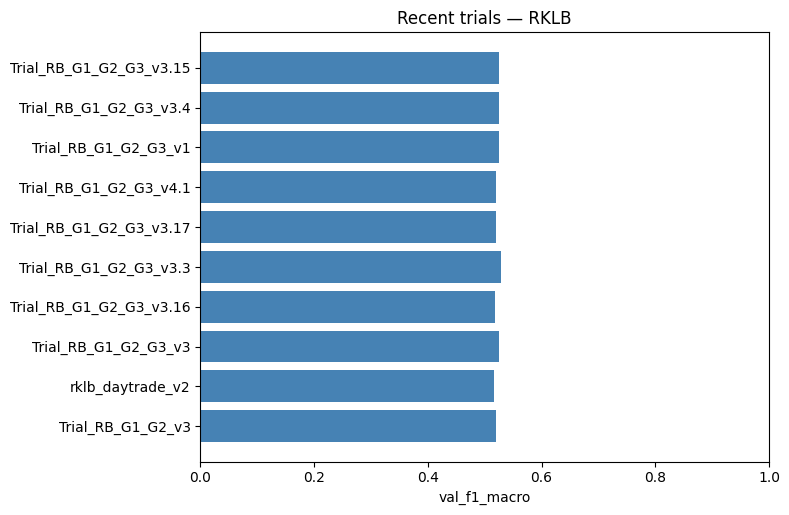

In [16]:
# Chart: prefer val_f1_macro (better for imbalanced labels), fall back to val_accuracy
import matplotlib.pyplot as plt

if log_path.is_file() and len(trials):
    plot_df = trials.copy()
    metric_col = "val_f1_macro" if "val_f1_macro" in plot_df.columns else "val_accuracy"
    plot_df = plot_df.dropna(subset=[metric_col])
    label_col = "train_experiment_name" if "train_experiment_name" in plot_df.columns else "run_id"
    plot_df["label"] = plot_df[label_col].fillna(plot_df["run_id"]).astype(str)
    plot_df = plot_df.sort_values(metric_col, ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df[metric_col], color="steelblue")
    ax.set_xlabel(metric_col)
    ax.set_title(f"Recent trials — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot yet.")

In [17]:
# Per-class val metrics for the latest run (or the one you just trained)

def load_latest_metrics(symbol: str, artifacts_dir: str = "artifacts") -> tuple[Path, dict]:
    sym_dir = REPO_ROOT / artifacts_dir / symbol.upper()
    if not sym_dir.is_dir():
        raise FileNotFoundError(sym_dir)
    runs = sorted(p for p in sym_dir.iterdir() if p.is_dir() and (p / "metrics.json").is_file())
    if not runs:
        raise FileNotFoundError("No runs with metrics.json")
    latest = runs[-1]
    return latest, json.loads((latest / "metrics.json").read_text(encoding="utf-8"))

run_dir = last_run_dir if last_run_dir is not None else load_latest_metrics(cfg.symbol)[0]
metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
report = metrics.get("classification_report_val", {})
rows = []
for name, stats in report.items():
    if isinstance(stats, dict) and "f1-score" in stats:
        rows.append({"class": name, **stats})
if rows:
    display(pd.DataFrame(rows).set_index("class")[["precision", "recall", "f1-score", "support"]])
    print("Run:", run_dir.name)
else:
    print("No classification_report_val in metrics.json")

,precision,recall,f1-score,support
class,,,,
stop_loss,0.559508,0.642072,0.597953,637.0
take_profit,0.122581,0.243590,0.163090,78.0
vertical,0.856307,0.749269,0.799220,1368.0
macro avg,0.512799,0.544977,0.520088,2083.0
weighted avg,0.738068,0.697552,0.713850,2083.0


Run: 20260621T213147_869961Z
